In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../src/models/saved")

# Load model and scaler
iso_forest = joblib.load(MODELS_DIR / "isolation_forest.pkl")
scaler     = joblib.load(MODELS_DIR / "scaler.pkl")

# Load data
X_test  = pd.read_csv(PROCESSED_DIR / "X_test.csv")
y_test  = pd.read_csv(PROCESSED_DIR / "y_test_evil.csv")['evil'].values
risk_scores = np.load(PROCESSED_DIR / "if_risk_scores.npy")

FEATURE_COLS = X_test.columns.tolist()
X_test_scaled = scaler.transform(X_test)

print(f"Model loaded ✅")
print(f"Features: {FEATURE_COLS}")

Model loaded ✅
Features: ['uid_root', 'uid_daemon', 'uid_external', 'is_failure', 'is_success', 'process_freq', 'process_rarity', 'is_rare_process', 'unknown_parent_child', 'args_entropy']


In [4]:
# Compress training background to 10 centroids (critical for speed)
# This is the TreeExplainer + kmeans optimization we planned
print("Building SHAP background with kmeans compression...")

X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_train_scaled = scaler.transform(X_train)

# kmeans reduces 763k rows → 10 representative centroids
background = shap.kmeans(X_train_scaled, 10)
explainer  = shap.TreeExplainer(iso_forest, background.data)

print(f"SHAP explainer ready ✅")
print(f"Background shape: {background.data.shape}")

Building SHAP background with kmeans compression...
SHAP explainer ready ✅
Background shape: (10, 10)


In [5]:
# Use stratified sample: 1000 evil + 1000 benign
evil_idx   = np.where(y_test == 1)[0]
benign_idx = np.where(y_test == 0)[0]

np.random.seed(42)
sample_evil   = np.random.choice(evil_idx,   min(1000, len(evil_idx)),   replace=False)
sample_benign = np.random.choice(benign_idx, min(1000, len(benign_idx)), replace=False)
sample_idx    = np.concatenate([sample_evil, sample_benign])

X_sample        = X_test_scaled[sample_idx]
y_sample        = y_test[sample_idx]
risk_sample     = risk_scores[sample_idx]

print(f"Computing SHAP values for {len(sample_idx)} events...")
print("This may take 2-5 minutes on your RTX 3060...")

shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation done ✅")

Computing SHAP values for 2000 events...
This may take 2-5 minutes on your RTX 3060...
SHAP values shape: (2000, 10)
SHAP computation done ✅


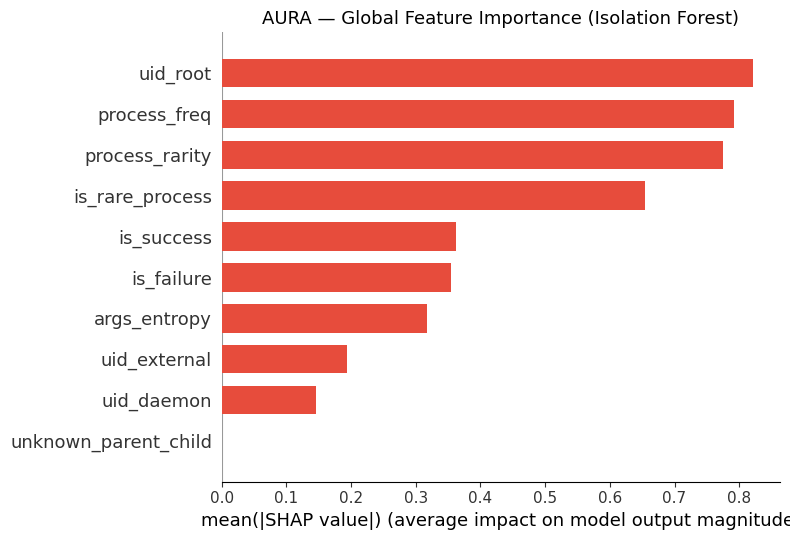

Global importance chart saved ✅


In [6]:
shap.initjs()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURE_COLS,
    plot_type="bar",
    show=False,
    color='#e74c3c'
)
plt.title("AURA — Global Feature Importance (Isolation Forest)", fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "shap_global_importance.png", dpi=150)
plt.show()
print("Global importance chart saved ✅")

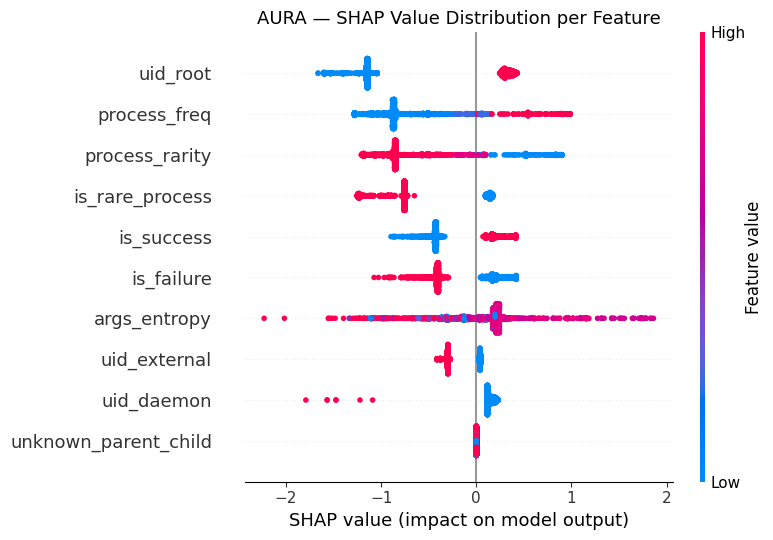

Beeswarm chart saved ✅


In [7]:
plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title("AURA — SHAP Value Distribution per Feature", fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "shap_beeswarm.png", dpi=150)
plt.show()
print("Beeswarm chart saved ✅")

In [ ]:
# Pick the highest-risk evil event in our sample
evil_in_sample  = np.where(y_sample == 1)[0]
highest_risk_idx = evil_in_sample[np.argmax(risk_sample[evil_in_sample])]

print("=== HIGH RISK EVENT ANALYSIS ===")
print(f"Risk Score : {risk_sample[highest_risk_idx]:.2f} / 100")
print(f"True Label : {'EVIL ⚠️' if y_sample[highest_risk_idx]==1 else 'Benign'}")
print(f"\nRaw Feature Values:")

event_df = pd.DataFrame(
    X_sample[highest_risk_idx:highest_risk_idx+1],
    columns=FEATURE_COLS
)
# Inverse transform to original scale for readability
event_original = scaler.inverse_transform(event_df)
event_readable = pd.DataFrame(event_original, columns=FEATURE_COLS)
print(event_readable.T.rename(columns={0: 'value'}))

print(f"\nSHAP Explanation (why it was flagged):")
feature_shap = dict(zip(FEATURE_COLS, shap_values[highest_risk_idx]))
sorted_shap  = sorted(feature_shap.items(), key=lambda x: abs(x[1]), reverse=True)

for feat, val in sorted_shap[:5]:
    # For IsolationForest: negative SHAP = pushes toward anomaly = INCREASES risk
    # positive SHAP = pushes toward normal = DECREASES risk
    direction = "↑ increases risk" if val < 0 else "↓ decreases risk"
    print(f"  {feat:25s}: SHAP={val:+.4f}  {direction}")

=== HIGH RISK EVENT ANALYSIS ===
Risk Score : 94.00 / 100
True Label : EVIL ⚠️

Raw Feature Values:
                      value
uid_root                0.0
uid_daemon              0.0
uid_external            1.0
is_failure              0.0
is_success              1.0
process_freq            0.0
process_rarity          1.0
is_rare_process         1.0
unknown_parent_child    1.0
args_entropy            1.0

SHAP Explanation (why it was flagged):
  uid_root                 : SHAP=-1.1504  ↓ decreases risk
  args_entropy             : SHAP=-0.9806  ↓ decreases risk
  process_freq             : SHAP=-0.9692  ↓ decreases risk
  process_rarity           : SHAP=-0.9167  ↓ decreases risk
  is_rare_process          : SHAP=-0.8751  ↓ decreases risk


In [ ]:
def explain_event(event_features: dict, iso_model, scaler, explainer,
                  feature_cols, risk_min, risk_max) -> dict:
    """
    Takes a raw event dict, returns risk score + top 3 SHAP reasons.
    This exact function gets called by FastAPI in Phase 5.
    """
    # Convert to scaled array
    raw = np.array([[event_features.get(c, 0) for c in feature_cols]])
    scaled = scaler.transform(raw)

    # Risk score
    raw_score  = iso_model.decision_function(scaled)[0]
    risk_score = float(np.clip(
        (-raw_score - risk_min) / (risk_max - risk_min) * 100, 0, 100
    ))

    # SHAP explanation
    shap_vals  = explainer.shap_values(scaled)[0]
    feat_shap  = dict(zip(feature_cols, shap_vals))
    top_reasons = sorted(feat_shap.items(), key=lambda x: abs(x[1]), reverse=True)[:3]

    # Map score to action
    if risk_score < 30:
        action = "ALLOW"
    elif risk_score < 70:
        action = "REVIEW / OTP"
    else:
        action = "BLOCK"

    return {
        "risk_score": round(risk_score, 2),
        "action": action,
        "top_reasons": [
            {
                "feature": f,
                "shap_value": round(v, 4),
                "impact": "increases_risk" if v < 0 else "decreases_risk"
            }
            for f, v in top_reasons
        ]
    }

# Test it with a sample event
scaler_params = np.load(PROCESSED_DIR / "scaler_params.npy")
test_event = dict(zip(FEATURE_COLS, X_test.iloc[evil_idx[0]].values))

result = explain_event(test_event, iso_forest, scaler, explainer,
                       FEATURE_COLS, scaler_params[0], scaler_params[1])

print("=== SAMPLE API RESPONSE ===")
print(json.dumps(result, indent=2))

# Save explainer for API use
joblib.dump(explainer, MODELS_DIR / "shap_explainer.pkl")
print("\nSHAP explainer saved ✅")

=== SAMPLE API RESPONSE ===
{
  "risk_score": 60.1,
  "action": "REVIEW / OTP",
  "top_reasons": [
    {
      "feature": "uid_root",
      "shap_value": -1.6035
    },
    {
      "feature": "args_entropy",
      "shap_value": -0.4445
    },
    {
      "feature": "uid_external",
      "shap_value": -0.354
    }
  ]
}

SHAP explainer saved ✅
